# Industrial Agent

## The Objective

Imagine Marco, a process engineer at an automotive supplier producing fuel injector bodies on an INDEX 6-spindle CNC turning machine. The plant runs 3 shifts, making ~2,000 parts per shift. Each spindle turns a steel bar down to a 12mm cylindrical body with a deep axial bore and threaded port — tolerances are ±0.004mm on the sealing surface.

He gets a message from the night shift operator:

> "We're seeing chatter marks on the bore of the last 200 parts from Spindle 3. Do we scrap the batch or can we keep running?"

Note: Chatter marks on a bore are wave-like or rippled surface imperfections caused by self-excited vibrations during machining. To eliminate them, engineers must increase setup rigidity, reduce cutting speed, adjust feed rates, check tool center alignment, and ensure the tool is sharp.

<img src="https://www.planlauf.com/wp-content/uploads/2025/04/Rattermarken_Innenrunddrehen_400x200.jpg">

Without the agent, Marco's next hour is spent pulling sensor logs from the machine controller, manually checking a 380-page PDF manual for tool replacement intervals, and judging vision system photos by eye to distinguish between "chatter" and "built-up edge" wear. He must decide whether to stop a line that costs €800/hour in downtime or risk scrapping parts at €4.20 each.

That is a stressful 90 minutes under pressure from both the shift supervisor and the quality manager.

### The Agent Solution

With the agent, Marco types into the chat:

> "Spindle 3 is leaving chatter marks on the bore. Last 200 parts affected. Do we stop the run? What does the manual say about this?"

The agent performs three automated actions:

1.  Queries the sensor database: Pulls readings showing tool wear at 224 min and torque spiking to 68 Nm (normally 41 Nm).
2.  Searches inspection records: Finds vision system photos flagged with a "circumferential chatter pattern" exceeding the quality threshold.
3.  Searches the PDF manual (RAG): Identifies the specific requirement to replace CBN inserts after 200 min and notes that torque increases above 40% indicate edge breakdown.

The agent responds in 25 seconds, confirming that the insert is past its limit and recommending a stop for Spindle 3 while noting the other five spindles are functioning normally.

### Project Concept

The core of this project involves correlating live sensor readings against PDF manual specifications, confirmed by visual inspection data to provide actionable maintenance intelligence.

### Modalities

These are the data sources the agent utilizes to make informed decisions:

* CSV: Sensor logs including tool wear minutes, torque (Nm), and temperature (°C) per spindle.
* PDF: INDEX multi-spindle CNC manuals containing insert replacement intervals, torque thresholds, and bore surface specs.
* Images: Vision system surface photos for Rz roughness classification and chatter pattern detection.



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

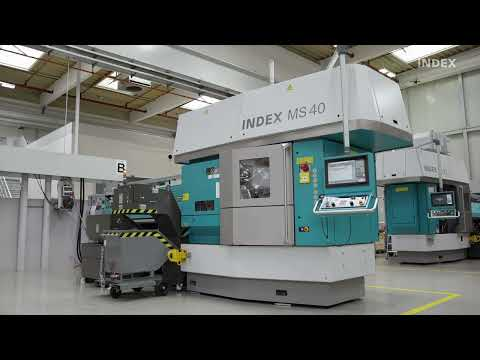

In [5]:
from IPython.display import Image, YouTubeVideo, display

video = YouTubeVideo(id='q9omlmHi-1Y', start=35, width=800, height=450)
display(video)

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601)

# data (as pandas dataframes)
X_raw = ai4i_2020_predictive_maintenance_dataset.data.features
y_raw = ai4i_2020_predictive_maintenance_dataset.data.targets

# metadata
print(ai4i_2020_predictive_maintenance_dataset.metadata)

# variable information
print(ai4i_2020_predictive_maintenance_dataset.variables)


{'uci_id': 601, 'name': 'AI4I 2020 Predictive Maintenance Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/601/data.csv', 'abstract': 'The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression', 'Causal-Discovery'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 10000, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], 'index_col': ['UID', 'Product ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C5HS5C', 'creators': [], 'intro_paper': {'ID': 386, 'type': 'NATIVE', 'title': 'Explainable Artificial Intelligen

The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset designed to mimic real-world industrial sensor data. It contains 10,000 rows and 14 columns, which can be categorized into identifiers, process features, and failure targets.

In the AI4I dataset, the "tool" refers to the cutting insert or drill bit.

### 1. Identifiers & Metadata
* **UDI**: A unique identifier for each data point (integers 1 to 10,000).
* **Product ID**: A combination of a quality letter (**L**ow, **M**edium, or **H**igh) and a serial number.
* **Type**: Simplified version of the Product ID, containing only the quality variant (L, M, or H).

### 2. Process Features (Sensors)
These represent the physical state of the machine during operation:
* **Air temperature [K]**: The ambient temperature, centered around 300 K.
* **Process temperature [K]**: The temperature of the actual process, typically ~10 K higher than the air temperature.
* **Rotational speed [rpm]**: Calculated based on a power of 2860 W with added noise.
* **Torque [Nm]**: The rotational force applied, normally distributed around 40 Nm.
* **Tool wear [min]**: This tracks how many minutes the sharp edge has been grinding against workpieces. As it wears down, it becomes dull. Relationship to Torque: A dull tool requires more Torque to cut through the same material, which is why those two columns are often correlated in predictive maintenance. The quality variants (H/M/L) increase this value at different rates (5/3/2 minutes respectively).

### 3. Target Variables (Failure Modes)
The dataset includes a primary binary label and five specific failure causes:
* **Machine failure**: A binary "umbrella" label. It is set to **1** if any of the following specific failures occur.
* **TWF (Tool Wear Failure)**: The tool fails or is replaced between 200–240 minutes of use.
* **HDF (Heat Dissipation Failure)**: Occurs if the difference between air and process temperature is < 8.6 K AND rotational speed is < 1380 rpm.
* **PWF (Power Failure)**: Occurs if the required power (Torque × Rad/s) is below 3500 W or above 9000 W.
* **OSF (Overstrain Failure)**: Occurs if the product of tool wear and torque exceeds specific thresholds based on the product quality (L, M, or H).
* **RNF (Random Failure)**: A 0.1% chance of failure regardless of process parameters.

In [7]:
X = (
    X_raw
    .rename(columns=lambda col: col.strip().lower().replace(' ', '_'))
    .assign(type=lambda df: df.type.astype('category'))
)
X

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9
...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14
9996,H,298.9,308.4,1632,31.8,17
9997,M,299.0,308.6,1645,33.4,22
9998,H,299.0,308.7,1408,48.5,25


In [8]:
y = (
    y_raw
    .rename(columns=lambda col: col.strip().lower().replace(' ', '_'))
)
y

,machine_failure,twf,hdf,pwf,osf,rnf
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
9995,0,0,0,0,0,0
9996,0,0,0,0,0,0
9997,0,0,0,0,0,0
9998,0,0,0,0,0,0


In [9]:
X_failed = X[y.machine_failure == 1]
X_failed

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear
50,L,298.9,309.1,2861,4.6,143
69,L,298.9,309.0,1410,65.7,191
77,L,298.8,308.9,1455,41.3,208
160,L,298.4,308.2,1282,60.7,216
161,L,298.3,308.1,1412,52.3,218
...,...,...,...,...,...,...
9758,L,298.6,309.8,2271,16.2,218
9764,L,298.5,309.5,1294,66.7,12
9822,L,298.5,309.4,1360,60.9,187
9830,L,298.3,309.3,1337,56.1,206


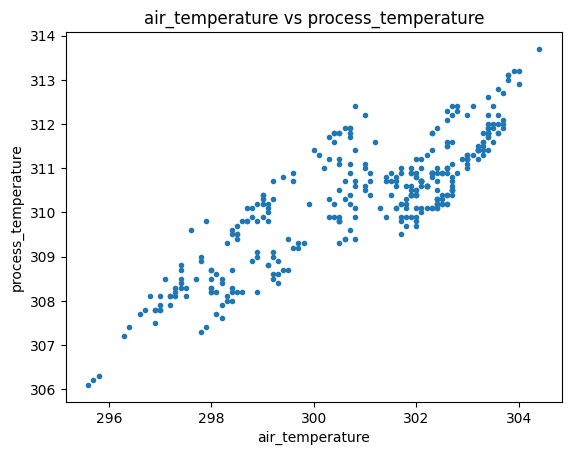

In [10]:
plt.scatter(X_failed.air_temperature, X_failed.process_temperature, marker='.')
plt.xlabel('air_temperature');
plt.ylabel('process_temperature')
plt.title('air_temperature vs process_temperature')
plt.show()

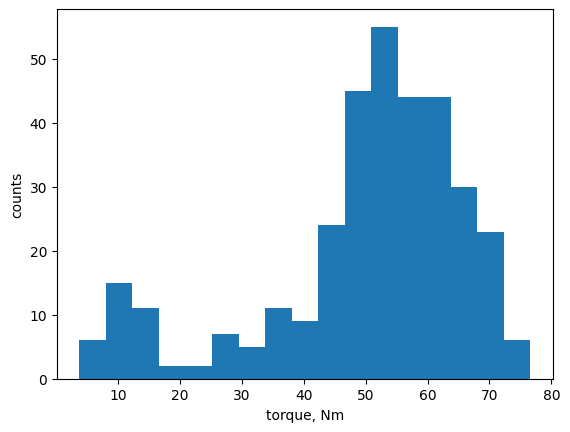

In [11]:
plt.hist(X_failed.torque, bins='fd')
plt.xlabel('torque, Nm');
plt.ylabel('counts')
plt.show()

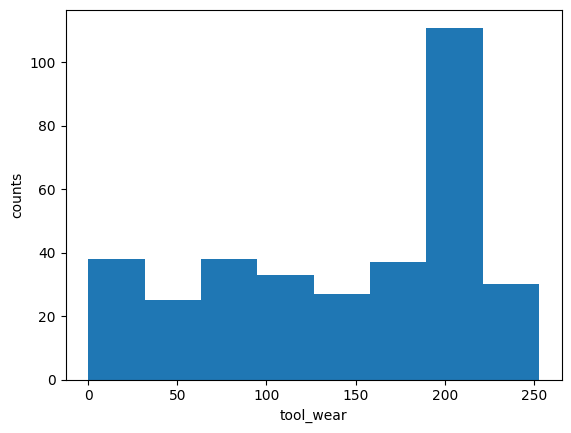

In [12]:
plt.hist(X_failed.tool_wear, bins='fd')
plt.xlabel('tool_wear');
plt.ylabel('counts')
plt.show()

In [13]:
X_failed.tool_wear.mean(), X_failed.tool_wear.std()

(np.float64(143.78171091445427), np.float64(72.75987593568681))

In [14]:
X_failed.torque.mean(), X_failed.torque.std()

(np.float64(50.16814159292036), np.float64(16.374498133978197))

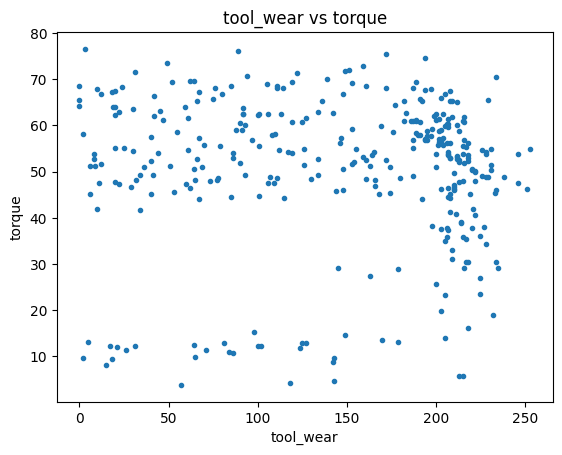

In [15]:
plt.scatter(X_failed.tool_wear, X_failed.torque, marker='.')
plt.xlabel('tool_wear');
plt.ylabel('torque')
plt.title('tool_wear vs torque')
plt.show()

In [16]:
X_good = X[y.machine_failure == 0]
X_good

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9
...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14
9996,H,298.9,308.4,1632,31.8,17
9997,M,299.0,308.6,1645,33.4,22
9998,H,299.0,308.7,1408,48.5,25


In [17]:
X.shape[0] == X_good.shape[0] + X_failed.shape[0]

True

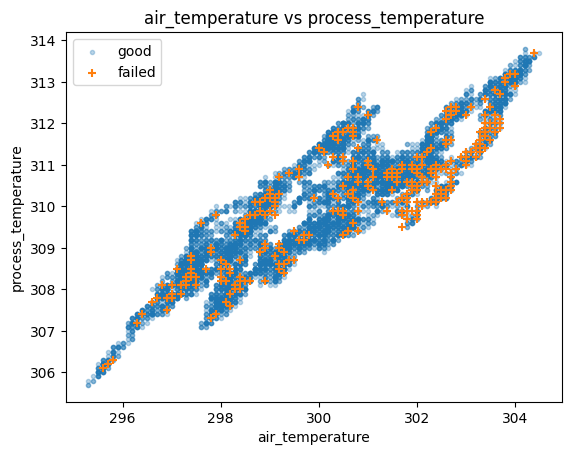

In [18]:
plt.scatter(X_good.air_temperature, X_good.process_temperature, marker='.', label='good', alpha=0.3)
plt.scatter(X_failed.air_temperature, X_failed.process_temperature, marker='+', label='failed')
plt.xlabel('air_temperature');
plt.ylabel('process_temperature')
plt.title('air_temperature vs process_temperature')
plt.legend()
plt.show()

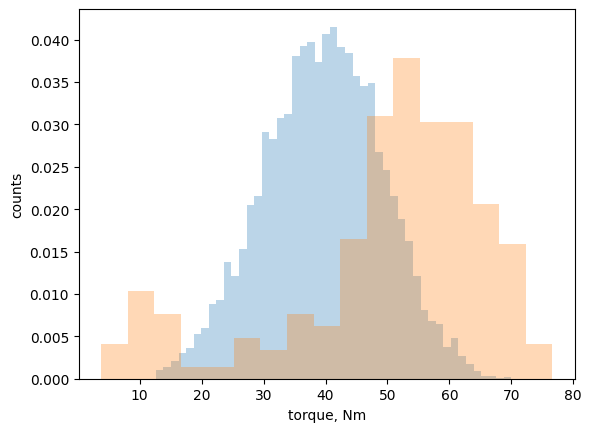

In [19]:
plt.hist(X_good.torque, bins='fd', density=True, alpha=0.3, label='good')
plt.hist(X_failed.torque, bins='fd', density=True, alpha=0.3, label='failed')
plt.xlabel('torque, Nm');
plt.ylabel('counts')
plt.show()

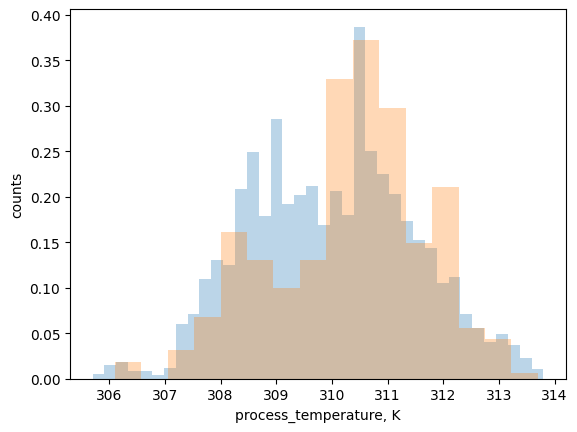

In [20]:
plt.hist(X_good.process_temperature, bins='fd', density=True, alpha=0.3, label='good')
plt.hist(X_failed.process_temperature, bins='fd', density=True, alpha=0.3, label='failed')
plt.xlabel('process_temperature, K');
plt.ylabel('counts')
plt.show()

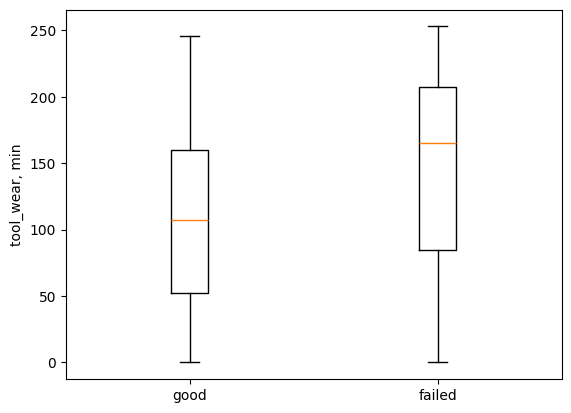

In [21]:
plt.boxplot([X_good.tool_wear, X_failed.tool_wear], tick_labels=['good', 'failed'])
plt.ylabel('tool_wear, min')
plt.show()

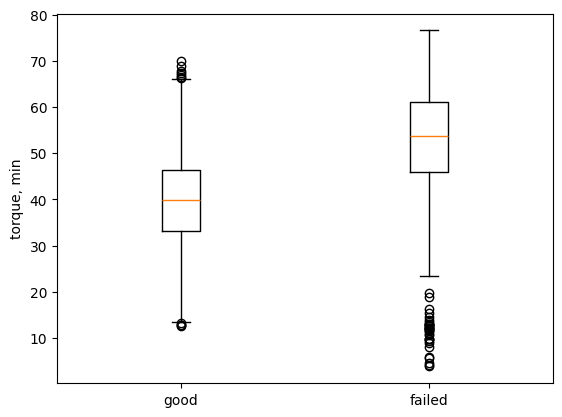

In [22]:
plt.boxplot([X_good.torque, X_failed.torque], tick_labels=['good', 'failed'])
plt.ylabel('torque, min')
plt.show()

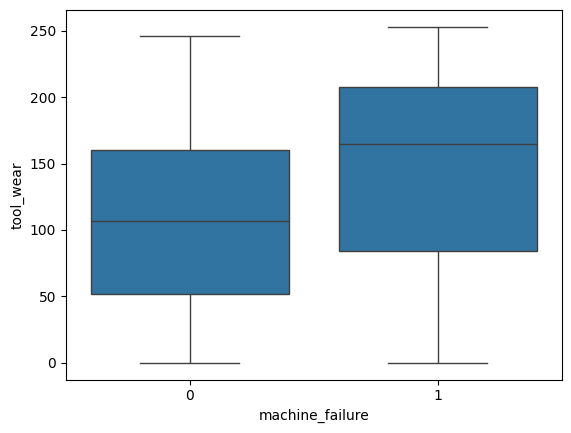

In [23]:
import seaborn as sns

sns.boxplot(x=y.machine_failure, y=X.tool_wear)
plt.show()

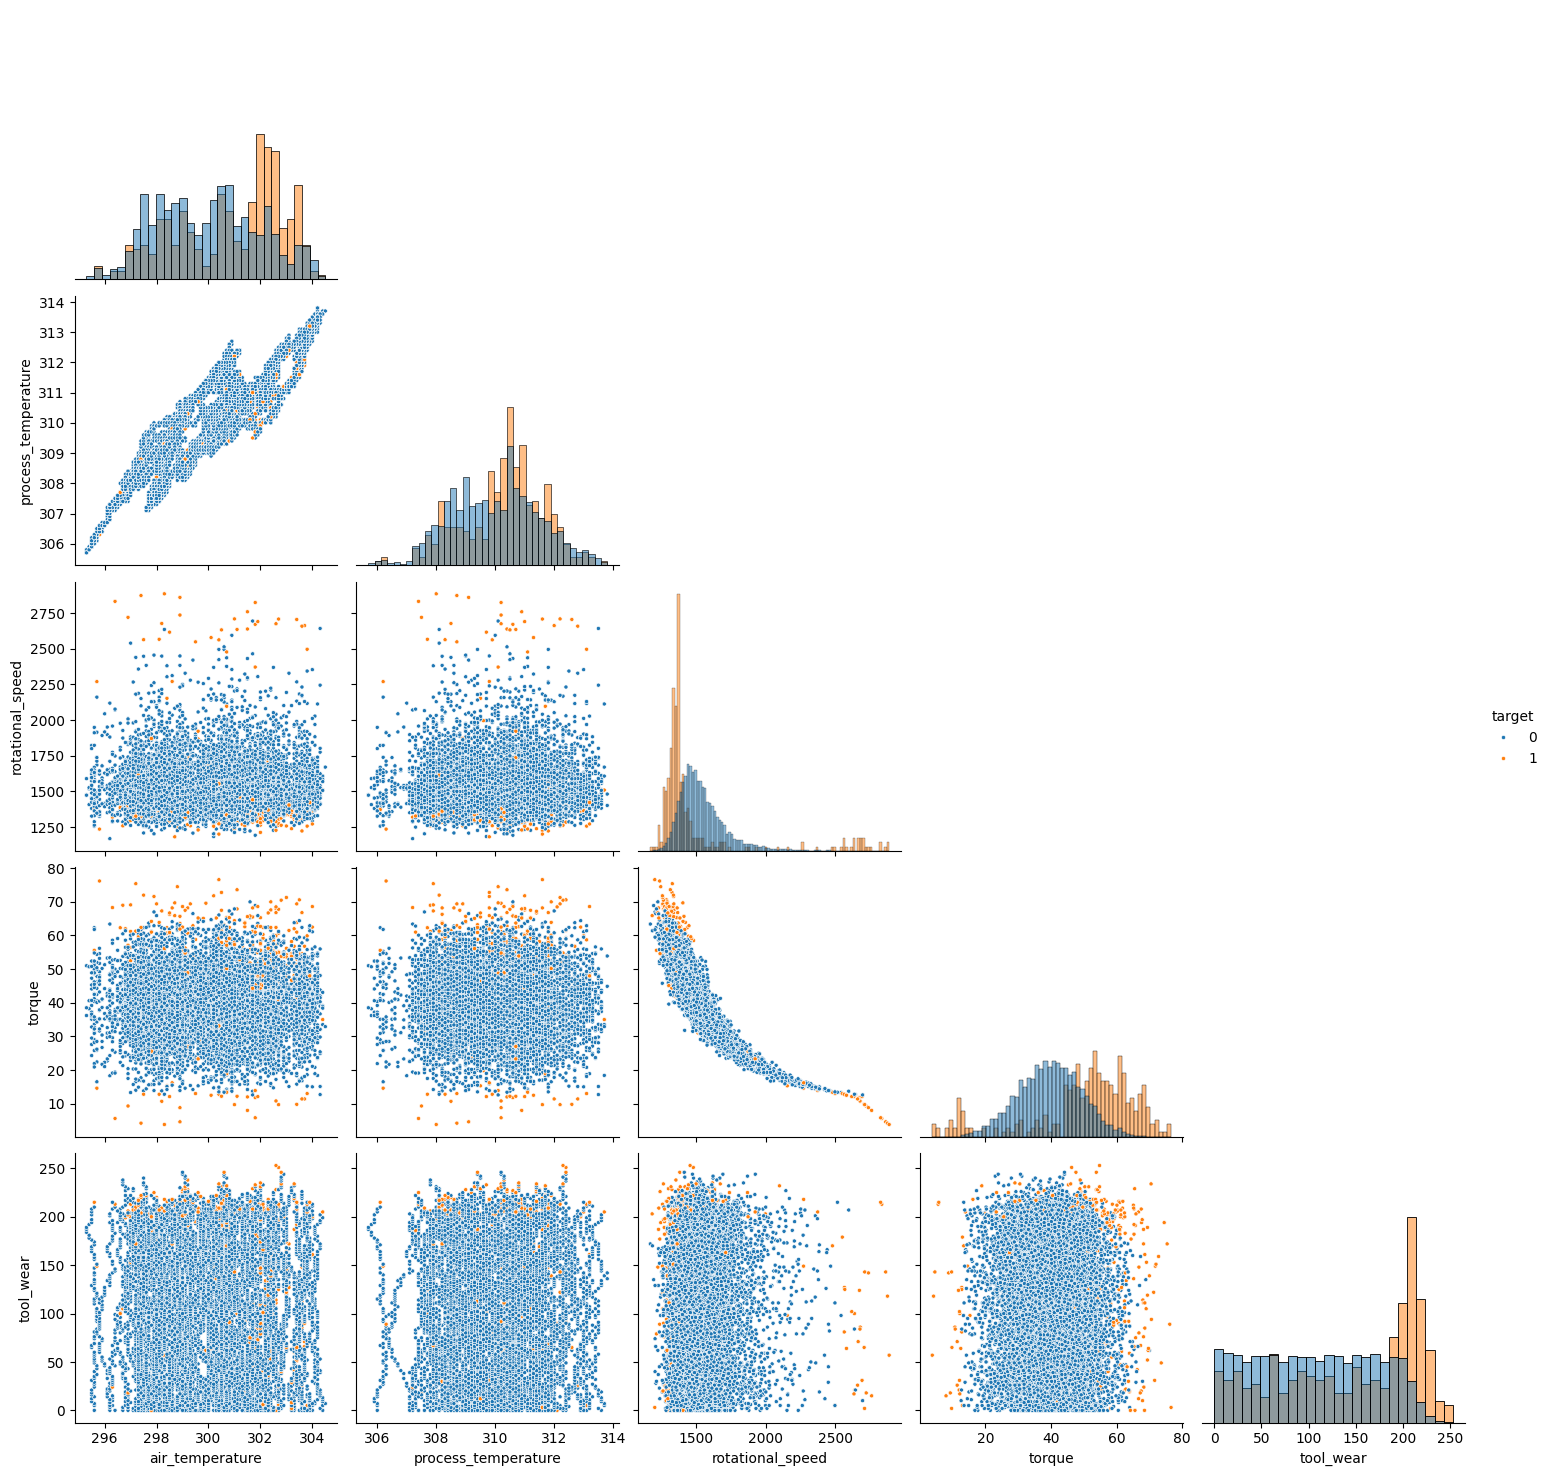

In [35]:
sns.pairplot(X.assign(target=y.machine_failure), hue='target', corner=True, height=3, diag_kind='hist',
             diag_kws={'stat': 'percent', 'common_norm': False}, markers=['.', '.'])
plt.show()